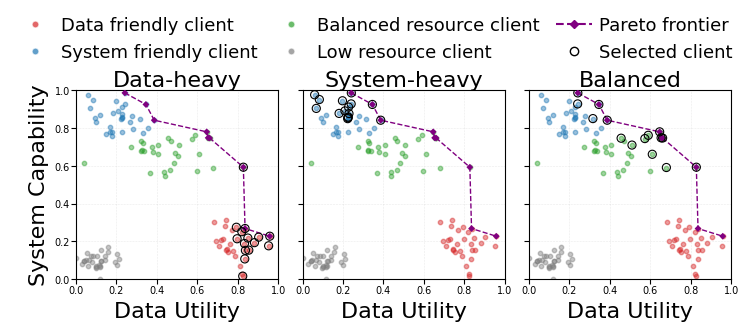

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_weighting_pareto_comparison(
    x_tick_fontsize=7,
    y_tick_fontsize=7,
    xlabel_fontsize=8,
    ylabel_fontsize=8,
    title_fontsize=8.5,
    legend_fontsize=7.5,
    legend_loc="upper center",
    legend_bbox_to_anchor=(0.5, 1.02),
    fig_width=7.2,
    fig_height=3.1,
    wspace=0.12,
    hspace=0.0,
    n_clients=120,
    k=15,
    show_legend=True,
    random_seed=42,
):
    """
    Plot three weighting strategies against the Pareto frontier for FL client selection.

    Parameters
    ----------
    x_tick_fontsize : int or float
        Font size of x-axis tick labels.
    y_tick_fontsize : int or float
        Font size of y-axis tick labels.
    xlabel_fontsize : int or float
        Font size of x-axis labels.
    ylabel_fontsize : int or float
        Font size of y-axis labels.
    title_fontsize : int or float
        Font size of subplot titles.
    legend_fontsize : int or float
        Font size of legend text.
    legend_loc : str
        Legend location string for fig.legend().
    legend_bbox_to_anchor : tuple
        Legend anchor for fig.legend().
    fig_width : float
        Width of the whole figure.
    fig_height : float
        Height of the whole figure.
    wspace : float
        Width spacing between subplots.
    hspace : float
        Height spacing between subplots.
    n_clients : int
        Total number of simulated clients. Should be divisible by 4.
    k : int
        Number of top selected clients to highlight.
    show_legend : bool
        Whether to show the legend above the figure.
    random_seed : int
        Random seed for reproducibility.

    Returns
    -------
    fig, axes
        Matplotlib figure and axes objects.
    """
    if n_clients % 4 != 0:
        raise ValueError("n_clients must be divisible by 4.")

    np.random.seed(random_seed)

    # ==========================================
    # 1. Simulate FL client data
    # ==========================================
    per_cluster = n_clients // 4

    c1 = np.random.multivariate_normal(
        [0.8, 0.2, 0.2],
        [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01]],
        per_cluster
    )
    c2 = np.random.multivariate_normal(
        [0.2, 0.9, 0.8],
        [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01]],
        per_cluster
    )
    c3 = np.random.multivariate_normal(
        [0.5, 0.5, 0.9],
        [[0.02, 0, 0], [0, 0.02, 0], [0, 0, 0.01]],
        per_cluster
    )
    c4 = np.random.multivariate_normal(
        [0.1, 0.1, 0.1],
        [[0.005, 0, 0], [0, 0.005, 0], [0, 0, 0.005]],
        per_cluster
    )

    X = np.vstack((c1, c2, c3, c4))
    X = np.clip(X, 0, 1)

    labels = np.array(
        ["C1"] * per_cluster +
        ["C2"] * per_cluster +
        ["C3"] * per_cluster +
        ["C4"] * per_cluster
    )

    cluster_colors = {
        "C1": "tab:red",
        "C2": "tab:blue",
        "C3": "tab:green",
        "C4": "tab:gray"
    }

    # ==========================================
    # 2. Build 2D axes for Pareto view
    # ==========================================
    data_utility = X[:, 0]
    system_capability = 0.6 * X[:, 1] + 0.4 * X[:, 2]
    points = np.column_stack((data_utility, system_capability))

    # ==========================================
    # 3. Pareto frontier computation
    # ==========================================
    def compute_pareto_frontier(pts: np.ndarray):
        is_pareto = np.ones(pts.shape[0], dtype=bool)
        for i in range(pts.shape[0]):
            for j in range(pts.shape[0]):
                if i != j:
                    if (
                        pts[j, 0] >= pts[i, 0]
                        and pts[j, 1] >= pts[i, 1]
                        and (pts[j, 0] > pts[i, 0] or pts[j, 1] > pts[i, 1])
                    ):
                        is_pareto[i] = False
                        break
        frontier = pts[is_pareto]
        frontier = frontier[np.argsort(frontier[:, 0])]
        return frontier, is_pareto

    pareto_points, pareto_mask = compute_pareto_frontier(points)

    # ==========================================
    # 4. Define three weighting strategies
    # ==========================================
    strategies = {
        "Data-heavy": np.array([0.85, 0.10, 0.05]),
        "System-heavy": np.array([0.10, 0.70, 0.20]),
        "Balanced": np.array([0.45, 0.35, 0.20]),
    }

    # ==========================================
    # 5. Plot
    # ==========================================
    fig, axes = plt.subplots(
        1, 3,
        figsize=(fig_width, fig_height),
        sharex=True,
        sharey=True
    )

    for ax, (title, weights) in zip(axes, strategies.items()):
        weights = weights / weights.sum()
        scores = X.dot(weights)
        top_idx = np.argsort(scores)[-k:]

        # scatter by cluster
        for cluster, color in cluster_colors.items():
            idx = labels == cluster
            ax.scatter(
                data_utility[idx],
                system_capability[idx],
                s=10,
                alpha=0.45,
                c=color
            )

        # pareto frontier
        ax.plot(
            pareto_points[:, 0],
            pareto_points[:, 1],
            linestyle="--",
            linewidth=1.0,
            color="purple"
        )
        ax.scatter(
            pareto_points[:, 0],
            pareto_points[:, 1],
            s=12,
            c="purple",
            marker="D",
            edgecolors="none",
            zorder=4
        )

        # selected clients
        ax.scatter(
            data_utility[top_idx],
            system_capability[top_idx],
            s=34,
            facecolors="none",
            edgecolors="black",
            linewidths=0.8,
            zorder=5
        )

        selected_pareto = np.sum(pareto_mask[top_idx])
        ax.text(
            0.03, 0.96,
            f"", #w=({weights[0]:.2f},{weights[1]:.2f},{weights[2]:.2f})\nP:{selected_pareto}/{k}
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=6.5,
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.75", alpha=0.9)
        )

        ax.set_title(title, fontsize=title_fontsize, pad=2)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle="--", alpha=0.25, linewidth=0.4)
        ax.tick_params(axis="x", labelsize=x_tick_fontsize, pad=1)
        ax.tick_params(axis="y", labelsize=y_tick_fontsize, pad=1)

    axes[0].set_ylabel("System Capability", fontsize=ylabel_fontsize)
    for ax in axes:
        ax.set_xlabel("Data Utility", fontsize=xlabel_fontsize)

    if show_legend:
        legend_handles = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red', markersize=5, alpha=0.7, label='Data friendly client'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=5, alpha=0.7, label='System friendly client'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green', markersize=5, alpha=0.7, label='Balanced resource client'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:gray', markersize=5, alpha=0.7, label='Low resource client'),
            Line2D([0], [0], marker='D', color='purple', linestyle='--', markersize=4, label='Pareto frontier'),
            Line2D([0], [0], marker='o', color='black', markerfacecolor='none', linestyle='None', markersize=6, label=f'Selected client')
        ]

        fig.legend(
            handles=legend_handles,
            loc=legend_loc,
            bbox_to_anchor=legend_bbox_to_anchor,
            ncol=3,
            frameon=False,
            fontsize=legend_fontsize,
            handletextpad=0.4,
            columnspacing=0.9
        )

    plt.subplots_adjust(
        left=0.085,
        right=0.995,
        top=0.83 if show_legend else 0.93,
        bottom=0.22,
        wspace=wspace,
        hspace=hspace
    )

    return fig, axes


# =========================
# Example usage
# =========================
fig, axes = plot_weighting_pareto_comparison(
    x_tick_fontsize=7,
    y_tick_fontsize=7,
    xlabel_fontsize=16,
    ylabel_fontsize=16,
    title_fontsize=16,
    legend_fontsize=13,
    legend_loc="upper center",
    legend_bbox_to_anchor=(0.5, 1.12),
    fig_width=7.2,
    fig_height=3.1,
    wspace=0.12,
    hspace=0.0,
)

plt.savefig("metric_weighting_problem.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_weighting_pareto_comparison(
    # ===== 统一字体控制 =====
    global_fontsize=None,

    # ===== 分项字体控制 =====
    x_tick_fontsize=7,
    y_tick_fontsize=7,
    xlabel_fontsize=8,
    ylabel_fontsize=8,
    title_fontsize=8.5,
    legend_fontsize=7.5,
    text_fontsize=6.5,

    # ===== legend 控制 =====
    show_legend=True,
    legend_loc="upper center",
    legend_bbox_to_anchor=(0.5, 1.02),
    legend_ncol=3,

    # ===== 整体图尺寸控制 =====
    fig_width=7.2,
    fig_height=3.1,

    # ===== 子图间隙控制 =====
    wspace=0.12,
    hspace=0.0,

    # ===== 子图 xy 范围控制 =====
    xlim=(0, 1),
    ylim=(0, 1),

    # ===== 数据相关参数 =====
    n_clients=120,
    k=15,
    random_seed=42,
):
    """
    Plot three weighting strategies against the Pareto frontier for FL client selection.

    Parameters
    ----------
    global_fontsize : int or float or None
        If not None, override all font sizes with this value.

    x_tick_fontsize, y_tick_fontsize : int or float
        Tick label font sizes for x/y axes.
    xlabel_fontsize, ylabel_fontsize : int or float
        Axis label font sizes.
    title_fontsize : int or float
        Subplot title font size.
    legend_fontsize : int or float
        Legend font size.
    text_fontsize : int or float
        Internal annotation text font size.

    show_legend : bool
        Whether to show the legend.
    legend_loc : str
        Legend location for fig.legend().
    legend_bbox_to_anchor : tuple
        Anchor for fig.legend().
    legend_ncol : int
        Number of legend columns.

    fig_width, fig_height : float
        Figure width and height.

    wspace, hspace : float
        Subplot spacing.

    xlim, ylim : tuple
        Axis limits for all subplots.

    n_clients : int
        Total number of simulated clients. Must be divisible by 4.
    k : int
        Number of highlighted selected clients.
    random_seed : int
        Random seed.

    Returns
    -------
    fig, axes
        Matplotlib figure and axes objects.
    """
    if n_clients % 4 != 0:
        raise ValueError("n_clients must be divisible by 4.")

    # ===== 全局字体覆盖 =====
    if global_fontsize is not None:
        x_tick_fontsize = global_fontsize
        y_tick_fontsize = global_fontsize
        xlabel_fontsize = global_fontsize
        ylabel_fontsize = global_fontsize
        title_fontsize = global_fontsize
        legend_fontsize = global_fontsize
        text_fontsize = global_fontsize

    np.random.seed(random_seed)

    # ==========================================
    # 1. Simulate FL client data
    # ==========================================
    per_cluster = n_clients // 4

    c1 = np.random.multivariate_normal(
        [0.8, 0.2, 0.2],
        [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01]],
        per_cluster
    )
    c2 = np.random.multivariate_normal(
        [0.2, 0.9, 0.8],
        [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01]],
        per_cluster
    )
    c3 = np.random.multivariate_normal(
        [0.5, 0.5, 0.9],
        [[0.02, 0, 0], [0, 0.02, 0], [0, 0, 0.01]],
        per_cluster
    )
    c4 = np.random.multivariate_normal(
        [0.1, 0.1, 0.1],
        [[0.005, 0, 0], [0, 0.005, 0], [0, 0, 0.005]],
        per_cluster
    )

    X = np.vstack((c1, c2, c3, c4))
    X = np.clip(X, 0, 1)

    labels = np.array(
        ["C1"] * per_cluster +
        ["C2"] * per_cluster +
        ["C3"] * per_cluster +
        ["C4"] * per_cluster
    )

    cluster_colors = {
        "C1": "tab:red",
        "C2": "tab:blue",
        "C3": "tab:green",
        "C4": "tab:gray"
    }

    # ==========================================
    # 2. Build 2D axes for Pareto view
    # ==========================================
    data_utility = X[:, 0]
    system_capability = 0.6 * X[:, 1] + 0.4 * X[:, 2]
    points = np.column_stack((data_utility, system_capability))

    # ==========================================
    # 3. Pareto frontier computation
    # ==========================================
    def compute_pareto_frontier(pts: np.ndarray):
        is_pareto = np.ones(pts.shape[0], dtype=bool)
        for i in range(pts.shape[0]):
            for j in range(pts.shape[0]):
                if i != j:
                    if (
                        pts[j, 0] >= pts[i, 0]
                        and pts[j, 1] >= pts[i, 1]
                        and (pts[j, 0] > pts[i, 0] or pts[j, 1] > pts[i, 1])
                    ):
                        is_pareto[i] = False
                        break
        frontier = pts[is_pareto]
        frontier = frontier[np.argsort(frontier[:, 0])]
        return frontier, is_pareto

    pareto_points, pareto_mask = compute_pareto_frontier(points)

    # ==========================================
    # 4. Define three weighting strategies
    # ==========================================
    strategies = {
        "Data-heavy": np.array([0.85, 0.10, 0.05]),
        "System-heavy": np.array([0.10, 0.70, 0.20]),
        "Balanced": np.array([0.45, 0.35, 0.20]),
    }

    # ==========================================
    # 5. Plot
    # ==========================================
    fig, axes = plt.subplots(
        1, 3,
        figsize=(fig_width, fig_height),
        sharex=True,
        sharey=True
    )

    for ax, (title, weights) in zip(axes, strategies.items()):
        weights = weights / weights.sum()
        scores = X.dot(weights)
        top_idx = np.argsort(scores)[-k:]

        # scatter by cluster
        for cluster, color in cluster_colors.items():
            idx = labels == cluster
            ax.scatter(
                data_utility[idx],
                system_capability[idx],
                s=10,
                alpha=0.45,
                c=color
            )

        # pareto frontier
        ax.plot(
            pareto_points[:, 0],
            pareto_points[:, 1],
            linestyle="--",
            linewidth=1.0,
            color="purple"
        )
        ax.scatter(
            pareto_points[:, 0],
            pareto_points[:, 1],
            s=12,
            c="purple",
            marker="D",
            edgecolors="none",
            zorder=4
        )

        # selected clients
        ax.scatter(
            data_utility[top_idx],
            system_capability[top_idx],
            s=34,
            facecolors="none",
            edgecolors="black",
            linewidths=0.8,
            zorder=5
        )

        selected_pareto = np.sum(pareto_mask[top_idx])
        ax.text(
            0.03, 0.96,
            f"P:{selected_pareto}/{k}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=text_fontsize,
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.75", alpha=0.9)，
        )

        ax.set_title(title, fontsize=title_fontsize, pad=2)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.grid(True, linestyle="--", alpha=0.25, linewidth=0.4)
        ax.tick_params(axis="x", labelsize=x_tick_fontsize, pad=1)
        ax.tick_params(axis="y", labelsize=y_tick_fontsize, pad=1)

    axes[0].set_ylabel("System Capability", fontsize=ylabel_fontsize)
    for ax in axes:
        ax.set_xlabel("Data Utility", fontsize=xlabel_fontsize)

    if show_legend:
        legend_handles = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red',
                   markersize=5, alpha=0.7, label='Data friendly client'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue',
                   markersize=5, alpha=0.7, label='System friendly client'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green',
                   markersize=5, alpha=0.7, label='Balanced resource client'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:gray',
                   markersize=5, alpha=0.7, label='Low resource client'),
            Line2D([0], [0], marker='D', color='purple', linestyle='--',
                   markersize=4, label='Pareto frontier'),
            Line2D([0], [0], marker='o', color='black', markerfacecolor='none',
                   linestyle='None', markersize=6, label='Selected client')
        ]

        fig.legend(
            handles=legend_handles,
            loc=legend_loc,
            bbox_to_anchor=legend_bbox_to_anchor,
            ncol=legend_ncol,
            frameon=False,
            fontsize=legend_fontsize,
            handletextpad=0.4,
            columnspacing=0.9
        )

    plt.subplots_adjust(
        left=0.085,
        right=0.995,
        top=0.83 if show_legend else 0.93,
        bottom=0.22,
        wspace=wspace,
        hspace=hspace
    )

    return fig, axes


# =========================
# Example usage
# =========================
fig, axes = plot_weighting_pareto_comparison(
    global_fontsize=None,      # 设成 12 / 14 可统一控制所有字体
    x_tick_fontsize=7,
    y_tick_fontsize=7,
    xlabel_fontsize=16,
    ylabel_fontsize=16,
    title_fontsize=16,
    legend_fontsize=13,
    text_fontsize=10,
    legend_loc="upper center",
    legend_bbox_to_anchor=(0.5, 1.12),
    legend_ncol=3,
    fig_width=7.2,
    fig_height=3.1,
    wspace=0.12,
    hspace=0.0,
    xlim=(0, 1),
    ylim=(0, 1),
)

plt.savefig("metric_weighting_problem.pdf", dpi=600, bbox_inches="tight")
plt.show()

SyntaxError: invalid character '，' (U+FF0C) (1033849588.py, line 249)

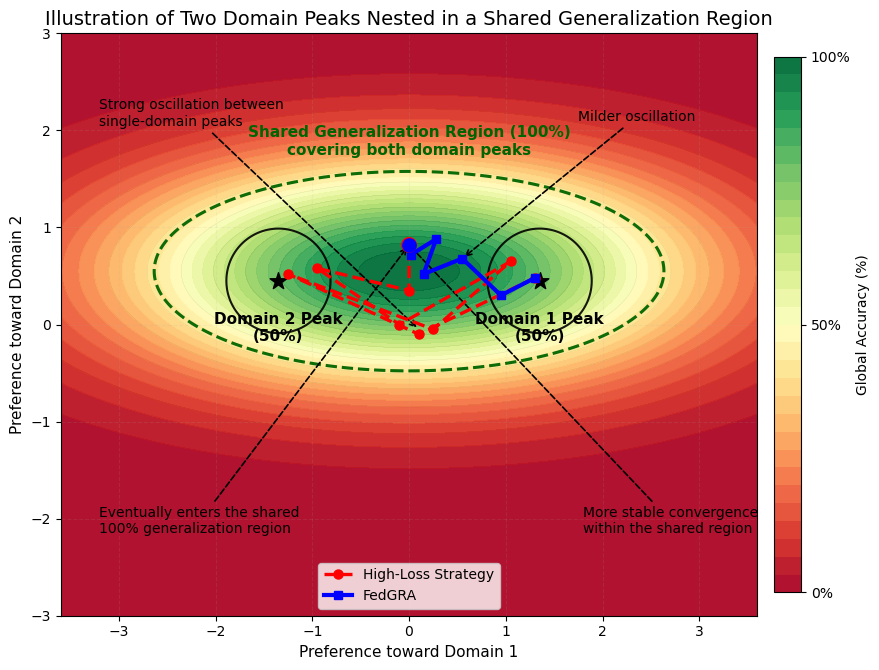

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_nested_generalization_landscape(
    figsize=(9.2, 6.8),
    title_fontsize=14,
    label_fontsize=11,
    text_fontsize=10,
    save_path=None,
    dpi=300
):
    # =================================
    # 1. Grid
    # =================================
    x = np.linspace(-3.6, 3.6, 600)
    y = np.linspace(-3.0, 3.0, 500)
    X, Y = np.meshgrid(x, y)

    # =================================
    # 2. Two small domain peaks (50%)
    # =================================
    d1 = (1.35, 0.45)
    d2 = (-1.35, 0.45)

    peak1 = 0.50 * np.exp(
        -(((X - d1[0]) ** 2) / (2 * 0.42 ** 2) +
          ((Y - d1[1]) ** 2) / (2 * 0.42 ** 2))
    )

    peak2 = 0.50 * np.exp(
        -(((X - d2[0]) ** 2) / (2 * 0.42 ** 2) +
          ((Y - d2[1]) ** 2) / (2 * 0.42 ** 2))
    )

    # =================================
    # 3. Large shared generalization region (100%)
    #    Designed like a canopy covering both peaks
    # =================================
    # Wide ellipse-like "big peak"
    big_region = 1.00 * np.exp(
        -((X ** 2) / (2 * 2.00 ** 2) +
          ((Y - 0.55) ** 2) / (2 * 0.78 ** 2))
    )

    # Use max to preserve semantic meaning:
    # small peaks remain 50%, big region reaches 100%
    Acc = np.maximum.reduce([peak1, peak2, big_region])
    Acc = np.clip(Acc, 0, 1)

    # =================================
    # 4. Plot background
    # =================================
    fig, ax = plt.subplots(figsize=figsize)

    levels = np.linspace(0, 1, 31)
    contour = ax.contourf(
        X, Y, Acc,
        levels=levels,
        cmap='RdYlGn',
        vmin=0,
        vmax=1,
        alpha=0.96
    )

    ax.contour(
        X, Y, Acc,
        levels=np.linspace(0.1, 0.9, 9),
        colors='k',
        linewidths=0.22,
        alpha=0.13
    )

    cbar = plt.colorbar(contour, ax=ax, shrink=0.92, pad=0.02)
    cbar.set_label("Global Accuracy (%)", fontsize=text_fontsize)
    cbar.set_ticks([0, 0.5, 1.0])
    cbar.set_ticklabels(["0%", "50%", "100%"])

    # =================================
    # 5. Draw explicit outlines like your sketch
    # =================================
    # Big shared region boundary
    ax.contour(
        X, Y, big_region,
        levels=[0.42],
        colors='darkgreen',
        linewidths=2.2,
        linestyles='--',
        alpha=0.95
    )

    # Small domain boundaries
    ax.contour(
        X, Y, peak1,
        levels=[0.22],
        colors='black',
        linewidths=1.5,
        alpha=0.9
    )
    ax.contour(
        X, Y, peak2,
        levels=[0.22],
        colors='black',
        linewidths=1.5,
        alpha=0.9
    )

    # =================================
    # 6. Markers and labels
    # =================================
    joint_center = (0.0, 0.75)

    ax.scatter(*d1, s=160, marker='*', color='black', zorder=6)
    ax.scatter(*d2, s=160, marker='*', color='black', zorder=6)

    ax.text(d1[0], d1[1]-0.62, "Domain 1 Peak\n(50%)",
            fontsize=label_fontsize, fontweight='bold',
            ha='center')
    ax.text(d2[0], d2[1]-0.62, "Domain 2 Peak\n(50%)",
            fontsize=label_fontsize, fontweight='bold',
            ha='center')

    ax.text(0.0, 1.75,
            "Shared Generalization Region (100%)\ncovering both domain peaks",
            fontsize=label_fontsize, fontweight='bold',
            ha='center', color='darkgreen')

    # =================================
    # 7. Optimization paths
    # =================================
    # High-loss: strong oscillation between peaks, then enters shared region
    path_a = np.array([
        [1.30, 0.48],
        [0.10, -0.10],
        [-1.25, 0.52],
        [0.25, -0.05],
        [1.05, 0.65],
        [-0.10, 0.00],
        [-0.95, 0.58],
        [0.00, 0.35],
        [0.00, 0.82],
    ])

    # FedGRA: milder oscillation, but not perfectly smooth
    path_b = np.array([
        [1.30, 0.48],
        [0.95, 0.30],
        [0.55, 0.68],
        [0.15, 0.52],
        [0.28, 0.88],
        [0.02, 0.72],
        [0.00, 0.82],
    ])

    ax.plot(
        path_a[:, 0], path_a[:, 1],
        '--o', color='red', lw=2.4, markersize=6.5,
        label='High-Loss Strategy', zorder=8
    )

    ax.plot(
        path_b[:, 0], path_b[:, 1],
        '-s', color='blue', lw=3.0, markersize=6.0,
        label='FedGRA', zorder=9
    )

    # Highlight endpoints
    ax.scatter(path_a[-1, 0], path_a[-1, 1], s=90, facecolors='none',
               edgecolors='red', linewidths=2.0, zorder=10)
    ax.scatter(path_b[-1, 0], path_b[-1, 1], s=90, facecolors='blue',
               edgecolors='blue', zorder=11)

    # =================================
    # 8. Annotations
    # =================================
    ax.annotate(
        "Strong oscillation between\nsingle-domain peaks",
        xy=(0.10, -0.05),
        xytext=(-3.2, 2.05),
        fontsize=text_fontsize,
        ha='left',
        arrowprops=dict(arrowstyle='->', lw=1.2, linestyle='--')
    )

    ax.annotate(
        "Eventually enters the shared\n100% generalization region",
        xy=(0.00, 0.82),
        xytext=(-3.2, -2.15),
        fontsize=text_fontsize,
        ha='left',
        arrowprops=dict(arrowstyle='->', lw=1.2, linestyle='--')
    )

    ax.annotate(
        "Milder oscillation",
        xy=(0.55, 0.68),
        xytext=(1.75, 2.1),
        fontsize=text_fontsize,
        ha='left',
        arrowprops=dict(arrowstyle='->', lw=1.2, linestyle='--')
    )

    ax.annotate(
        "More stable convergence\nwithin the shared region",
        xy=(0.00, 0.82),
        xytext=(1.8, -2.15),
        fontsize=text_fontsize,
        ha='left',
        arrowprops=dict(arrowstyle='->', lw=1.2, linestyle='--')
    )

    # =================================
    # 9. Formatting
    # =================================
    ax.set_title(
        "Illustration of Two Domain Peaks Nested in a Shared Generalization Region",
        fontsize=title_fontsize
    )
    ax.set_xlabel("Preference toward Domain 1", fontsize=label_fontsize)
    ax.set_ylabel("Preference toward Domain 2", fontsize=label_fontsize)

    ax.set_xlim(-3.6, 3.6)
    ax.set_ylim(-3.0, 3.0)
    ax.grid(alpha=0.12, linestyle='--')

    ax.legend(loc='lower center', fontsize=10, frameon=True)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()


# Run
plot_nested_generalization_landscape()

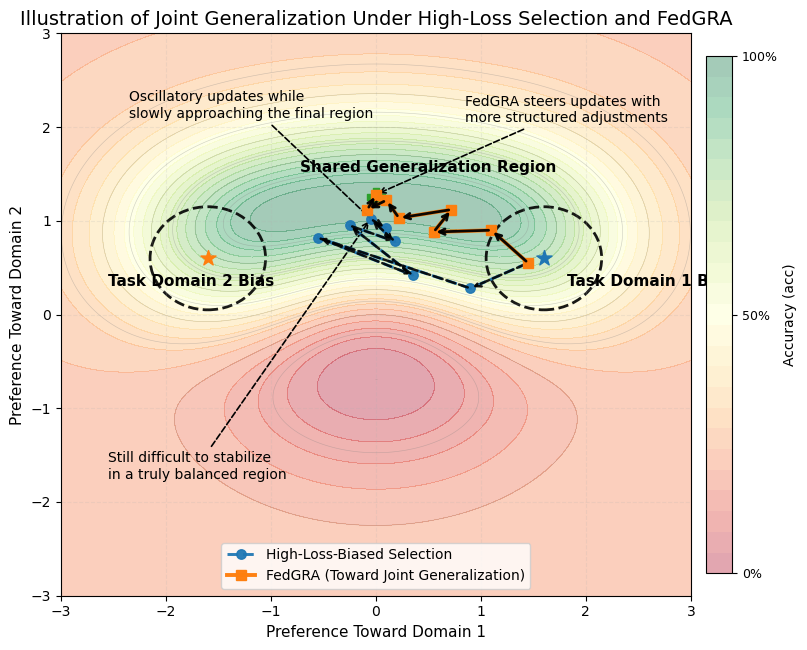

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

def plot_joint_generalization_process(
    figsize=(8.4, 6.6),
    title_fontsize=14,
    label_fontsize=11,
    text_fontsize=10,
    save_path=None,
    dpi=300
):
    # -----------------------------
    # 1. Construct a toy joint-generalization landscape
    # -----------------------------
    x = np.linspace(-3, 3, 300)
    y = np.linspace(-3, 3, 300)
    X, Y = np.meshgrid(x, y)

    # Two domain preference fields
    domain1 = np.exp(-((X - 1.4) ** 2 / 1.2 + (Y - 0.8) ** 2 / 1.0))
    domain2 = np.exp(-((X + 1.4) ** 2 / 1.2 + (Y - 0.8) ** 2 / 1.0))

    # Shared balanced region around the center-top
    shared = 1.25 * np.exp(-((X) ** 2 / 1.8 + (Y - 1.2) ** 2 / 0.9))

    # Lower interference / unstable zone in the middle-lower area
    unstable = 0.55 * np.exp(-((X) ** 2 / 2.5 + (Y + 0.3) ** 2 / 1.8))

    # Final landscape
    Z_raw = domain1 + domain2 + shared - unstable

    # Normalize to [0, 1] so the colorbar can be shown as accuracy
    Z = (Z_raw - Z_raw.min()) / (Z_raw.max() - Z_raw.min())

    fig, ax = plt.subplots(figsize=figsize)

    contour = ax.contourf(X, Y, Z, levels=24, cmap='RdYlGn', alpha=0.36)
    ax.contour(X, Y, Z, levels=10, colors='gray', linewidths=0.45, alpha=0.35)

    cbar = plt.colorbar(contour, ax=ax, shrink=0.92, pad=0.02)
    cbar.set_label("Accuracy (acc)", fontsize=text_fontsize)
    cbar.set_ticks([0.0, 0.5, 1.0])
    cbar.set_ticklabels(["0%", "50%", "100%"])
    cbar.ax.tick_params(labelsize=9)

    # -----------------------------
    # 2. Domain anchors
    # -----------------------------
    d1 = (1.6, 0.6)
    d2 = (-1.6, 0.6)
    joint = (0.0, 1.25)

    ax.scatter(*d1, s=130, marker='*', zorder=6)
    ax.scatter(*d2, s=130, marker='*', zorder=6)
    ax.scatter(*joint, s=180, marker='P', zorder=7)

    # Highlight the two domain regions with circles
    circle1 = Circle(d1, radius=0.55, fill=False, linewidth=2.0, linestyle='--', alpha=0.9)
    circle2 = Circle(d2, radius=0.55, fill=False, linewidth=2.0, linestyle='--', alpha=0.9)
    ax.add_patch(circle1)
    ax.add_patch(circle2)

    ax.text(1.82, 0.30, "Task Domain 1 Bias", fontsize=label_fontsize, fontweight='bold')
    ax.text(-2.55, 0.30, "Task Domain 2 Bias", fontsize=label_fontsize, fontweight='bold')
    ax.text(-0.72, 1.52, "Shared Generalization Region", fontsize=label_fontsize, fontweight='bold')

    # -----------------------------
    # 3. High-loss strategy path
    # -----------------------------
    # Gradually moves toward final region, but with oscillation and instability
    path_a = np.array([
        [1.45, 0.55],
        [0.90, 0.28],
        [-0.55, 0.82],
        [0.35, 0.42],
        [-0.25, 0.95],
        [0.18, 0.78],
        [-0.05, 1.02],
        [0.10, 0.92],
    ])

    ax.plot(
        path_a[:, 0], path_a[:, 1],
        '--o',
        lw=2.1,
        markersize=6.8,
        alpha=0.94,
        label='High-Loss-Biased Selection',
        zorder=8
    )

    # Add arrows along High-loss path
    for i in range(len(path_a) - 1):
        ax.annotate(
            "",
            xy=path_a[i + 1],
            xytext=path_a[i],
            arrowprops=dict(
                arrowstyle="->",
                lw=1.8,
                linestyle='--',
                shrinkA=2,
                shrinkB=2,
                alpha=0.9
            ),
            zorder=9
        )

    # -----------------------------
    # 4. FedGRA strategy path
    # -----------------------------
    # Less smooth, more stepwise adjustment toward balanced region
    path_b = np.array([
        [1.45, 0.55],
        [1.10, 0.90],
        [0.55, 0.88],
        [0.72, 1.12],
        [0.22, 1.03],
        [0.10, 1.22],
        [-0.08, 1.12],
        [0.00, 1.28],
    ])

    ax.plot(
        path_b[:, 0], path_b[:, 1],
        '-s',
        lw=2.8,
        markersize=6.5,
        alpha=0.98,
        label='FedGRA (Toward Joint Generalization)',
        zorder=10
    )

    # Add arrows along FedGRA path
    for i in range(len(path_b) - 1):
        ax.annotate(
            "",
            xy=path_b[i + 1],
            xytext=path_b[i],
            arrowprops=dict(
                arrowstyle="->",
                lw=2.0,
                shrinkA=2,
                shrinkB=2,
                alpha=0.95
            ),
            zorder=11
        )

    # -----------------------------
    # 5. Annotations
    # -----------------------------
    ax.annotate(
        "Oscillatory updates while\nslowly approaching the final region",
        xy=(0.18, 0.78),
        xytext=(-2.35, 2.10),
        fontsize=text_fontsize,
        ha='left',
        arrowprops=dict(arrowstyle='->', lw=1.2, linestyle='--')
    )

    ax.annotate(
        "Still difficult to stabilize\nin a truly balanced region",
        xy=(-0.05, 1.02),
        xytext=(-2.55, -1.75),
        fontsize=text_fontsize,
        ha='left',
        arrowprops=dict(arrowstyle='->', lw=1.2, linestyle='--')
    )

    ax.annotate(
        "FedGRA steers updates with\nmore structured adjustments",
        xy=(0.00, 1.28),
        xytext=(0.85, 2.05),
        fontsize=text_fontsize,
        ha='left',
        arrowprops=dict(arrowstyle='->', lw=1.2, linestyle='--')
    )

    # -----------------------------
    # 6. Formatting
    # -----------------------------
    ax.set_title(
        "Illustration of Joint Generalization Under High-Loss Selection and FedGRA",
        fontsize=title_fontsize
    )
    ax.set_xlabel("Preference Toward Domain 1", fontsize=label_fontsize)
    ax.set_ylabel("Preference Toward Domain 2", fontsize=label_fontsize)
    ax.legend(fontsize=10, loc='lower center', frameon=True)

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.grid(alpha=0.18, linestyle='--')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()


# Run
plot_joint_generalization_process()

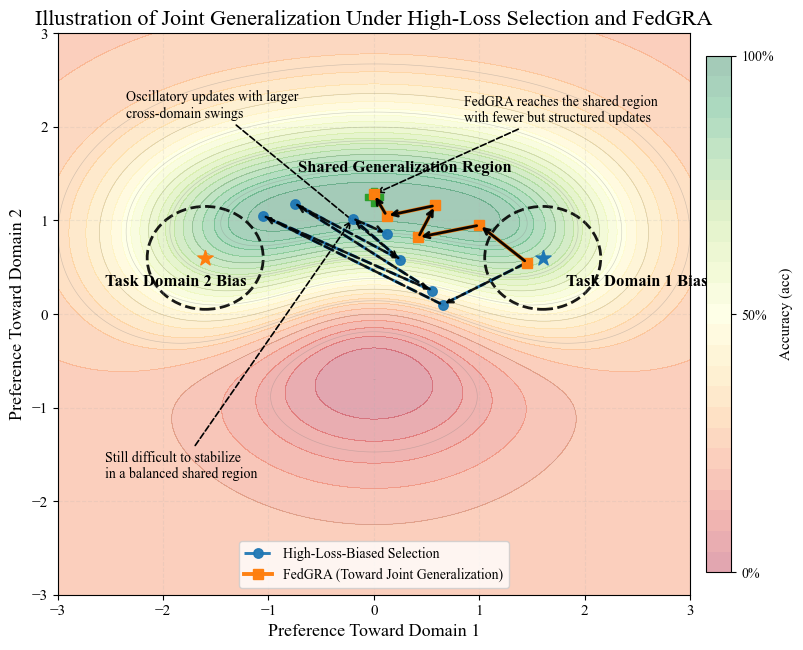

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

def plot_joint_generalization_process(
    figsize=(8.4, 6.6),

    # -----------------------------
    # Font size controls
    # -----------------------------
    title_fontsize=14,
    xlabel_fontsize=11,
    ylabel_fontsize=11,
    xtick_fontsize=10,
    ytick_fontsize=10,
    cbar_label_fontsize=10,
    cbar_tick_fontsize=9,
    legend_fontsize=10,
    domain_label_fontsize=11,
    annotation_fontsize=10,

    # -----------------------------
    # Line / marker / style controls
    # -----------------------------
    highloss_linewidth=2.1,
    fedgra_linewidth=2.8,
    highloss_markersize=6.8,
    fedgra_markersize=6.5,
    domain_circle_radius=0.55,

    save_path=None,
    dpi=300
):
    # -----------------------------
    # Global font: Times New Roman
    # -----------------------------
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['mathtext.fontset'] = 'stix'

    # -----------------------------
    # 1. Construct a toy joint-generalization landscape
    # -----------------------------
    x = np.linspace(-3, 3, 300)
    y = np.linspace(-3, 3, 300)
    X, Y = np.meshgrid(x, y)

    domain1 = np.exp(-((X - 1.4) ** 2 / 1.2 + (Y - 0.8) ** 2 / 1.0))
    domain2 = np.exp(-((X + 1.4) ** 2 / 1.2 + (Y - 0.8) ** 2 / 1.0))
    shared = 1.25 * np.exp(-((X) ** 2 / 1.8 + (Y - 1.2) ** 2 / 0.9))
    unstable = 0.55 * np.exp(-((X) ** 2 / 2.5 + (Y + 0.3) ** 2 / 1.8))

    Z_raw = domain1 + domain2 + shared - unstable
    Z = (Z_raw - Z_raw.min()) / (Z_raw.max() - Z_raw.min())

    fig, ax = plt.subplots(figsize=figsize)

    contour = ax.contourf(X, Y, Z, levels=24, cmap='RdYlGn', alpha=0.36)
    ax.contour(X, Y, Z, levels=10, colors='gray', linewidths=0.45, alpha=0.35)

    # -----------------------------
    # Colorbar: acc from 0% to 100%
    # -----------------------------
    cbar = plt.colorbar(contour, ax=ax, shrink=0.92, pad=0.02)
    cbar.set_label("Accuracy (acc)", fontsize=cbar_label_fontsize)
    cbar.set_ticks([0.0, 0.5, 1.0])
    cbar.set_ticklabels(["0%", "50%", "100%"])
    cbar.ax.tick_params(labelsize=cbar_tick_fontsize)

    # -----------------------------
    # 2. Domain anchors
    # -----------------------------
    d1 = (1.6, 0.6)
    d2 = (-1.6, 0.6)
    joint = (0.0, 1.25)

    ax.scatter(*d1, s=130, marker='*', zorder=6)
    ax.scatter(*d2, s=130, marker='*', zorder=6)
    ax.scatter(*joint, s=180, marker='P', zorder=7)

    circle1 = Circle(
        d1,
        radius=domain_circle_radius,
        fill=False,
        linewidth=2.0,
        linestyle='--',
        alpha=0.9
    )
    circle2 = Circle(
        d2,
        radius=domain_circle_radius,
        fill=False,
        linewidth=2.0,
        linestyle='--',
        alpha=0.9
    )
    ax.add_patch(circle1)
    ax.add_patch(circle2)

    ax.text(
        1.82, 0.30, "Task Domain 1 Bias",
        fontsize=domain_label_fontsize,
        fontweight='bold'
    )
    ax.text(
        -2.55, 0.30, "Task Domain 2 Bias",
        fontsize=domain_label_fontsize,
        fontweight='bold'
    )
    ax.text(
        -0.72, 1.52, "Shared Generalization Region",
        fontsize=domain_label_fontsize,
        fontweight='bold'
    )

    # -----------------------------
    # 3. High-loss strategy path
    # Larger oscillation
    # -----------------------------
    path_a = np.array([
        [1.45, 0.55],
        [0.65, 0.10],
        [-1.05, 1.05],
        [0.55, 0.25],
        [-0.75, 1.18],
        [0.25, 0.58],
        [-0.20, 1.02],
        [0.12, 0.86],
    ])

    ax.plot(
        path_a[:, 0], path_a[:, 1],
        '--o',
        lw=highloss_linewidth,
        markersize=highloss_markersize,
        alpha=0.94,
        label='High-Loss-Biased Selection',
        zorder=8
    )

    for i in range(len(path_a) - 1):
        ax.annotate(
            "",
            xy=path_a[i + 1],
            xytext=path_a[i],
            arrowprops=dict(
                arrowstyle="->",
                lw=1.8,
                linestyle='--',
                shrinkA=2,
                shrinkB=2,
                alpha=0.9
            ),
            zorder=9
        )

    # -----------------------------
    # 4. FedGRA strategy path
    # Only 5 updates -> 6 points total
    # -----------------------------
    path_b = np.array([
        [1.45, 0.55],   # start
        [1.00, 0.95],   # update 1
        [0.42, 0.82],   # update 2
        [0.58, 1.16],   # update 3
        [0.12, 1.05],   # update 4
        [0.00, 1.28],   # update 5 / final
    ])

    ax.plot(
        path_b[:, 0], path_b[:, 1],
        '-s',
        lw=fedgra_linewidth,
        markersize=fedgra_markersize,
        alpha=0.98,
        label='FedGRA (Toward Joint Generalization)',
        zorder=10
    )

    for i in range(len(path_b) - 1):
        ax.annotate(
            "",
            xy=path_b[i + 1],
            xytext=path_b[i],
            arrowprops=dict(
                arrowstyle="->",
                lw=2.0,
                shrinkA=2,
                shrinkB=2,
                alpha=0.95
            ),
            zorder=11
        )

    # -----------------------------
    # 5. Annotations
    # -----------------------------
    ax.annotate(
        "Oscillatory updates with larger\ncross-domain swings",
        xy=(0.25, 0.58),
        xytext=(-2.35, 2.10),
        fontsize=annotation_fontsize,
        ha='left',
        arrowprops=dict(
            arrowstyle='->',
            lw=1.2,
            linestyle='--'
        )
    )

    ax.annotate(
        "Still difficult to stabilize\nin a balanced shared region",
        xy=(-0.20, 1.02),
        xytext=(-2.55, -1.75),
        fontsize=annotation_fontsize,
        ha='left',
        arrowprops=dict(
            arrowstyle='->',
            lw=1.2,
            linestyle='--'
        )
    )

    ax.annotate(
        "FedGRA reaches the shared region\nwith fewer but structured updates",
        xy=(0.00, 1.28),
        xytext=(0.85, 2.05),
        fontsize=annotation_fontsize,
        ha='left',
        arrowprops=dict(
            arrowstyle='->',
            lw=1.2,
            linestyle='--'
        )
    )

    # -----------------------------
    # 6. Formatting
    # -----------------------------
    ax.set_title(
        "Illustration of Joint Generalization Under High-Loss Selection and FedGRA",
        fontsize=title_fontsize
    )
    ax.set_xlabel(
        "Preference Toward Domain 1",
        fontsize=xlabel_fontsize
    )
    ax.set_ylabel(
        "Preference Toward Domain 2",
        fontsize=ylabel_fontsize
    )

    ax.tick_params(axis='x', labelsize=xtick_fontsize)
    ax.tick_params(axis='y', labelsize=ytick_fontsize)

    ax.legend(fontsize=legend_fontsize, loc='lower center', frameon=True)

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.grid(alpha=0.18, linestyle='--')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()


# Run
plot_joint_generalization_process(
    title_fontsize=16,
    xlabel_fontsize=13,
    ylabel_fontsize=13,
    xtick_fontsize=11,
    ytick_fontsize=11,
    cbar_label_fontsize=11,
    cbar_tick_fontsize=10,
    legend_fontsize=10,
    domain_label_fontsize=12,
    annotation_fontsize=10
)